<a href="https://colab.research.google.com/github/AlanChi0720/bio_ai/blob/main/D_singlecell_pbmc.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tour D: Single-Cell Biology — PBMC Cell Type Clustering

**The idea:** scRNA-seq measures gene expression in thousands of individual cells at once. Each cell gets a vector of ~20,000 gene expression values. By clustering these vectors, we can discover distinct cell populations — without knowing in advance how many types exist or what they are.

**What we'll build:** Process the PBMC 3k dataset (peripheral blood mononuclear cells from a healthy donor), cluster the cells, and identify T cells, B cells, monocytes, and NK cells using known marker genes.

**Estimated time:** 2–3 hours  
**PBMC 3k is the "Hello World" of single-cell biology.** Every scRNA-seq paper references this type of analysis.

In [1]:
!pip install -q scanpy leidenalg python-igraph

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 939.8 kB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.2/91.2 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 11.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.7/2.7 MB 36.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.7/5.7 MB 62.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 174.3/174.3 kB 10.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 41.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 295.7/295.7 kB 17.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 56.3 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2

In [2]:
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt

sc.settings.verbosity = 1
sc.settings.set_figure_params(dpi=100, facecolor='white')
print('Scanpy version:', sc.__version__)

Scanpy version: 1.12.1


/tmp/ipykernel_27823/3459356634.py:6: FutureWarning: Use `scanpy.set_figure_params` instead
  sc.settings.set_figure_params(dpi=100, facecolor='white')
/tmp/ipykernel_27823/3459356634.py:7: FutureWarning: `__version__` is deprecated, use `importlib.metadata.version('scanpy')` instead
  print('Scanpy version:', sc.__version__)


## 1. Load Data

The PBMC 3k dataset (2,700 cells, ~33k genes) is built into scanpy.

In [3]:
adata = sc.datasets.pbmc3k()
print(adata)
# AnnData object: rows = cells, columns = genes

  0%|          | 0.00/5.58M [00:00<?, ?B/s]

AnnData object with n_obs × n_vars = 2700 × 32738
    var: 'gene_ids'


## 2. Quality Control

Real scRNA-seq data contains dead cells (high mitochondrial gene fraction) and empty droplets (very few detected genes). We filter these out.

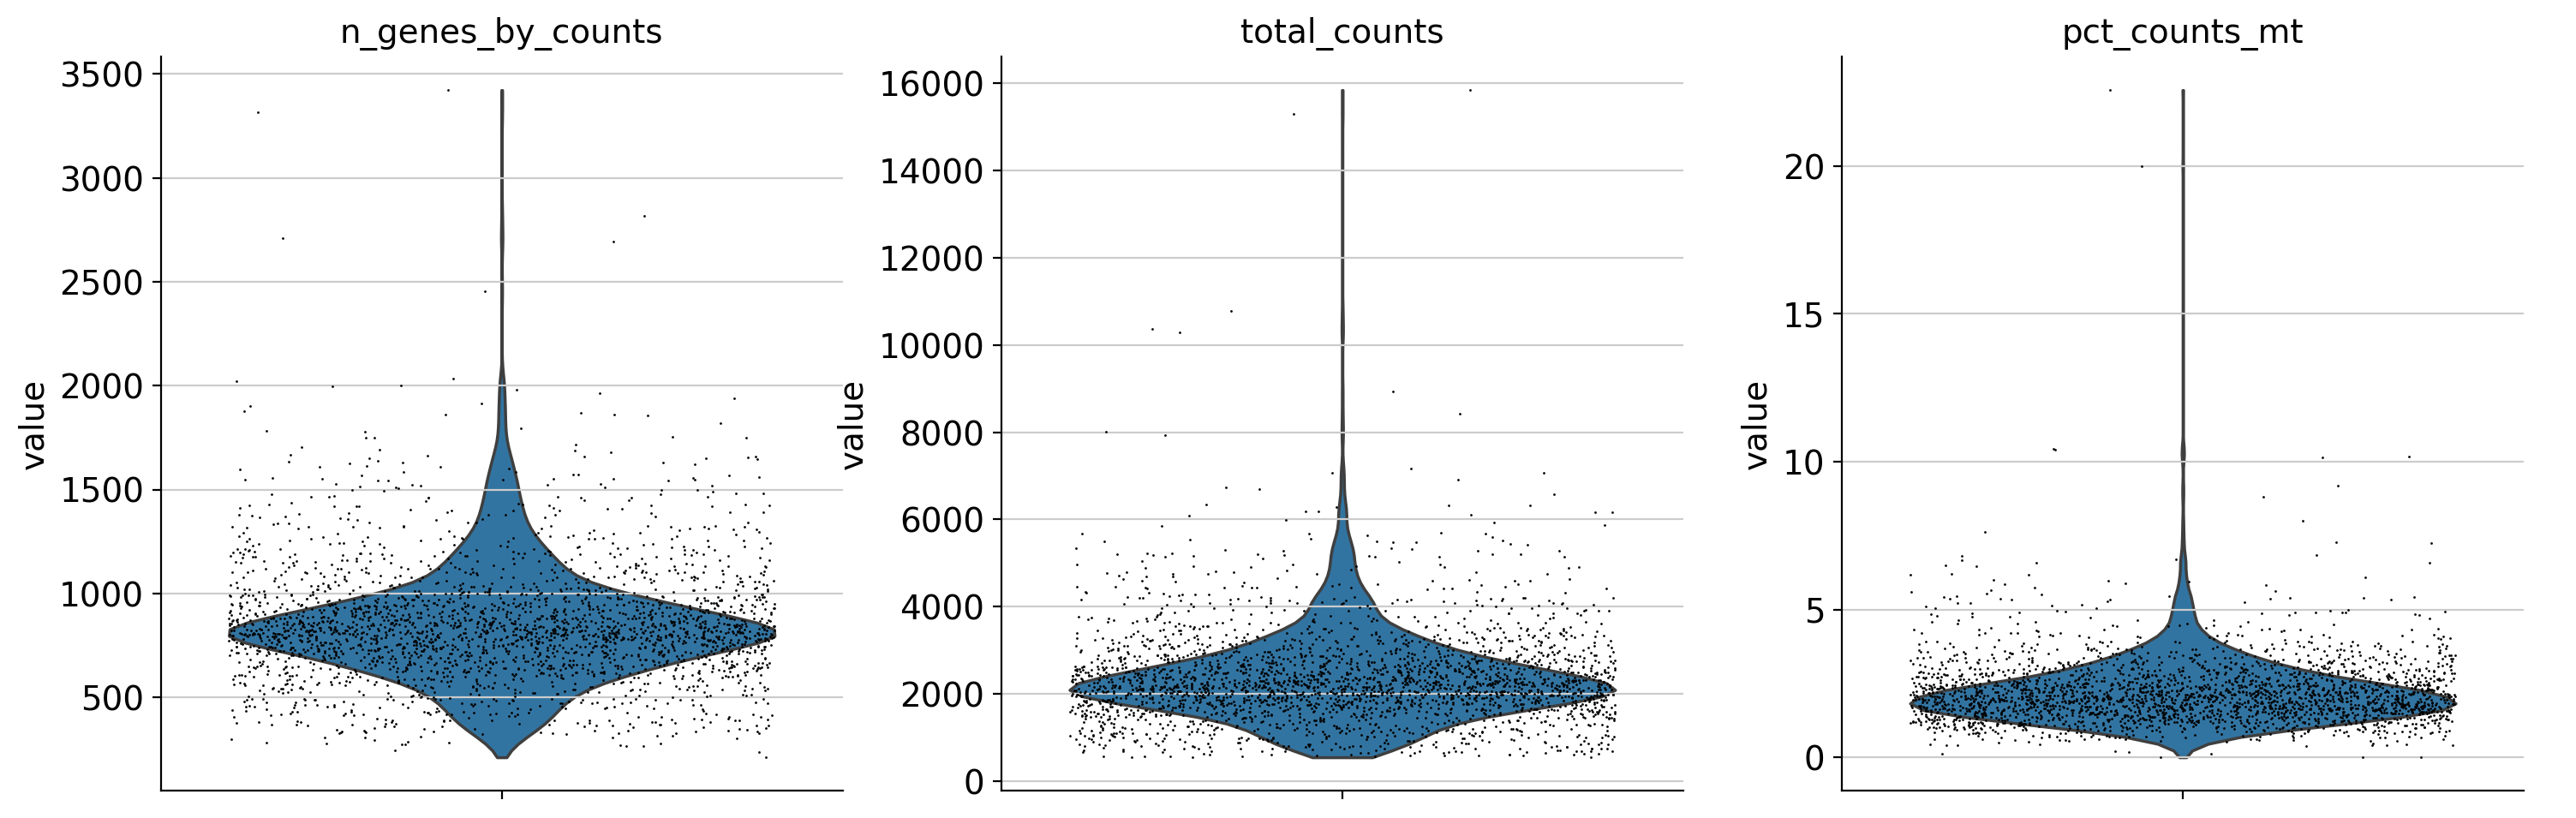

In [4]:
# Annotate mitochondrial genes (gene names starting with 'MT-')
adata.var['mt'] = adata.var_names.str.startswith('MT-')
sc.pp.calculate_qc_metrics(adata, qc_vars=['mt'], percent_top=None, log1p=False, inplace=True)

sc.pl.violin(adata,
             ['n_genes_by_counts', 'total_counts', 'pct_counts_mt'],
             jitter=0.4, multi_panel=True)
# Q: Can you see outlier cells with unusually high mitochondrial % (likely dead cells)?

In [5]:
# Filter: keep cells with 200–2500 genes detected, and <5% mitochondrial reads
sc.pp.filter_cells(adata, min_genes=200)
sc.pp.filter_cells(adata, max_genes=2500)
sc.pp.filter_genes(adata, min_cells=3)
adata = adata[adata.obs['pct_counts_mt'] < 5].copy()
print(f'Cells after QC: {adata.n_obs}')

Cells after QC: 2638


## 3. Normalization and Feature Selection

Raw counts vary by cell (some cells were sequenced deeper). We normalize so each cell has the same total count, then log-transform to stabilize variance.

In [6]:
sc.pp.normalize_total(adata, target_sum=1e4)  # normalize to 10,000 counts per cell
sc.pp.log1p(adata)  # log(x+1) transform

# Select highly variable genes (the ones that differ most across cells)
sc.pp.highly_variable_genes(adata, min_mean=0.0125, max_mean=3, min_disp=0.5)
print(f'Highly variable genes: {adata.var.highly_variable.sum()}')

adata = adata[:, adata.var.highly_variable].copy()

Highly variable genes: 1830


## 4. Dimensionality Reduction

Going from ~2,000 genes down to 2D for visualization, in two steps: PCA (to ~50 dimensions) then UMAP (to 2D).

/usr/lib/python3.12/functools.py:912: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


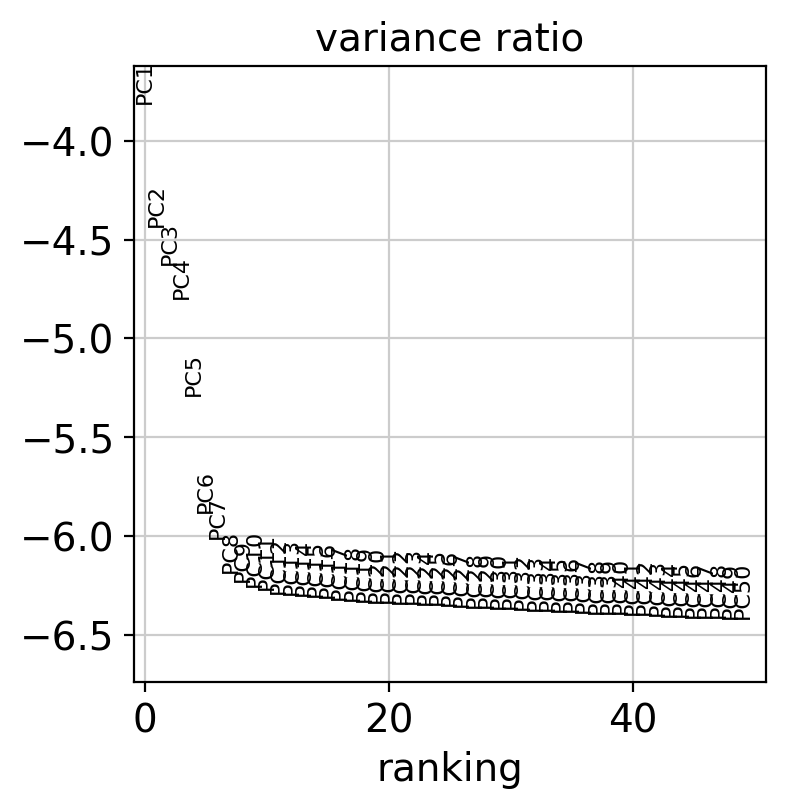

In [7]:
sc.pp.scale(adata, max_value=10)
sc.tl.pca(adata, svd_solver='arpack')
sc.pl.pca_variance_ratio(adata, log=True, n_pcs=50)
# Q: How many PCs do you need before the variance explained flattens out?

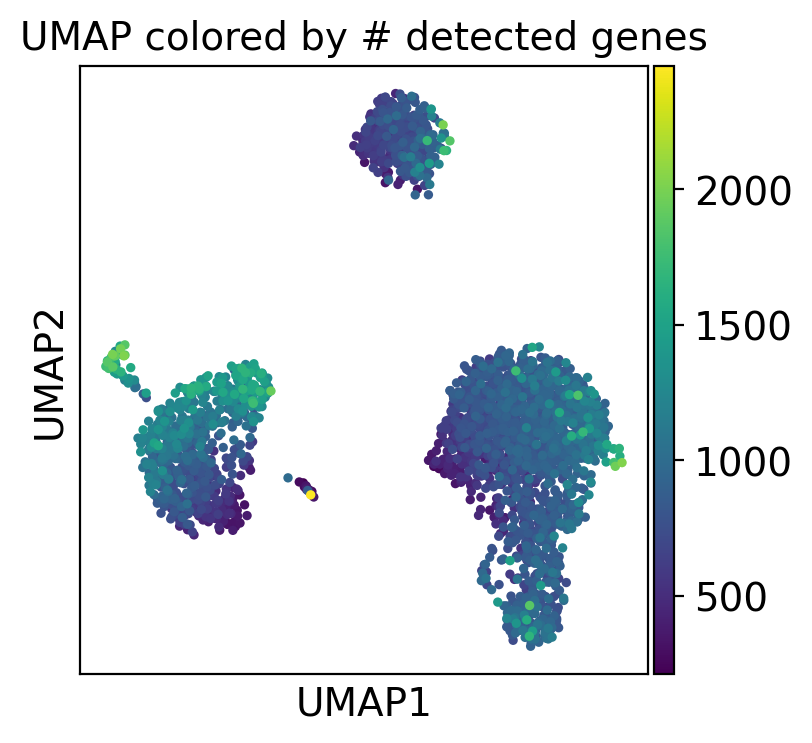

In [8]:
sc.pp.neighbors(adata, n_neighbors=10, n_pcs=40)
sc.tl.umap(adata)
sc.pl.umap(adata, color='n_genes_by_counts', title='UMAP colored by # detected genes')
# You should see multiple distinct clouds of points = candidate cell populations

## 5. Leiden Clustering

Leiden is a graph-based clustering algorithm. `resolution` controls granularity: higher = more clusters.

/tmp/ipykernel_27823/2118543071.py:2: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(adata, resolution=res, key_added=f'leiden_{res}')
/tmp/ipykernel_27823/2118543071.py:2: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(adata, resolution=res, key_added=f

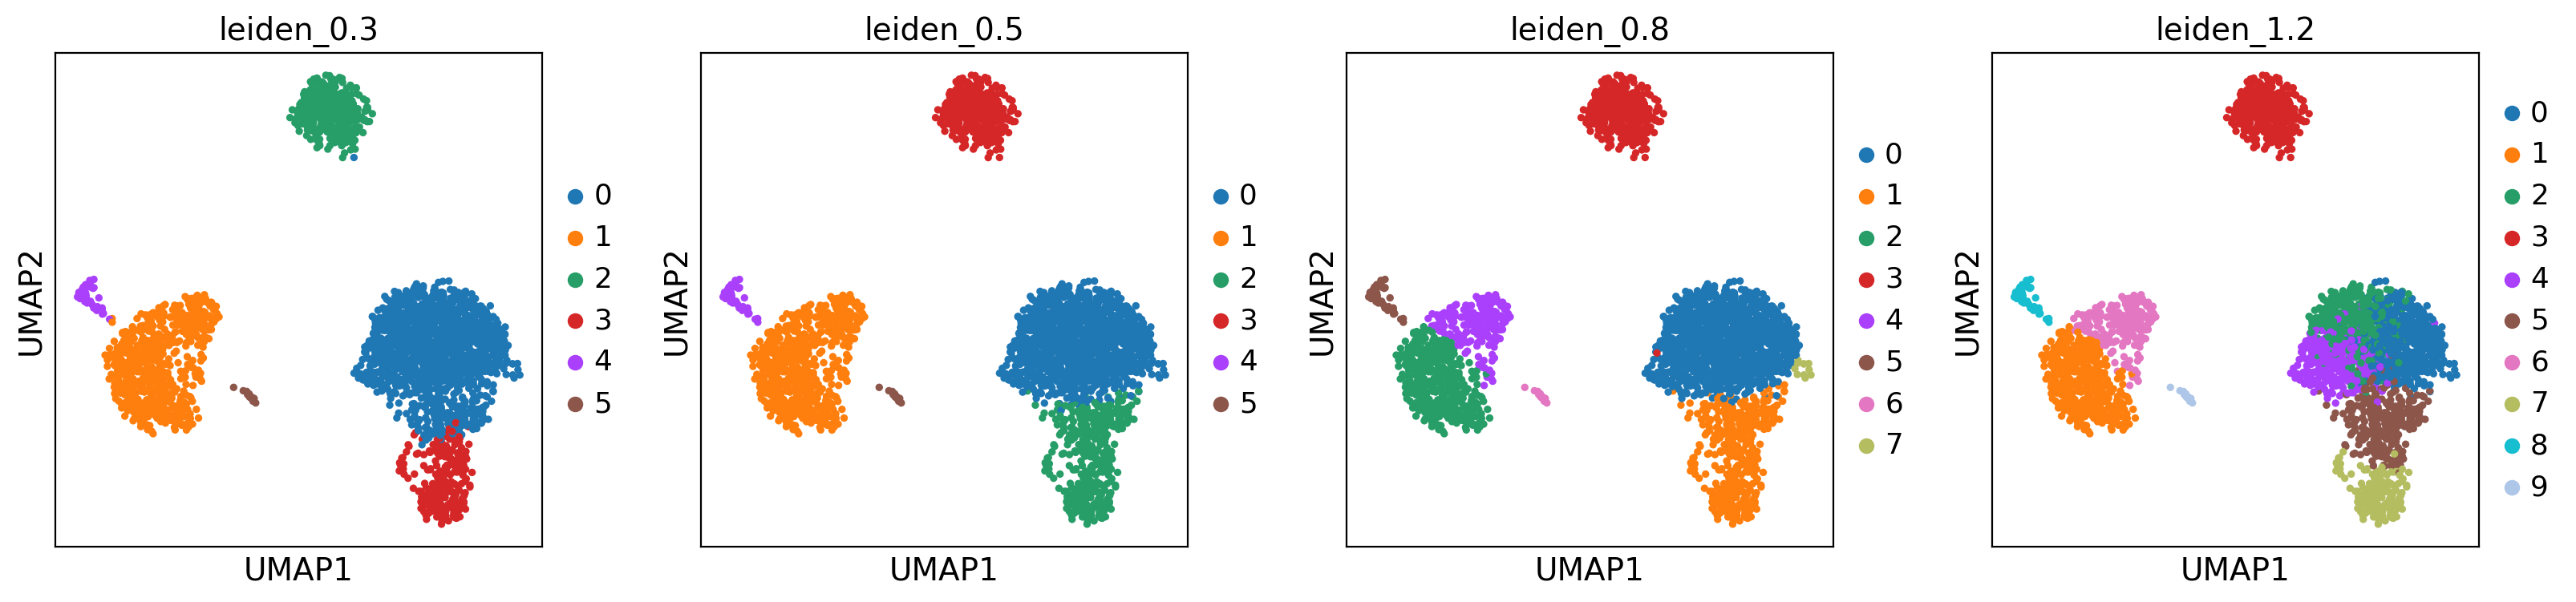

In [16]:
for res in [0.3, 0.5, 0.8, 1.2]:
    sc.tl.leiden(adata, resolution=res, key_added=f'leiden_{res}')

sc.pl.umap(adata, color=['leiden_0.3', 'leiden_0.5', 'leiden_0.8', 'leiden_1.2'])

# Try changing resolution to 0.3 (fewer clusters) or 0.8 (more clusters)
# Q: What resolution gives biologically meaningful separation?

## 6. Cell Type Annotation Using Marker Genes

These are well-established marker genes for blood cell types:

| Marker | Cell type |
|---|---|
| CD3D, IL7R | T cells |
| CD19, MS4A1 (CD20) | B cells |
| CD14, LYZ | Monocytes |
| GNLY, NKG7 | NK cells |
| FCER1A | Dendritic cells |

In [18]:
# 看 var_names 的前幾個，確認格式
print(adata.var_names[:20].tolist())

# 搜尋看看 CD3 相關的基因
import pandas as pd
matches = [g for g in adata.var_names if 'CD3' in g.upper()]
print("CD3 相關：", matches)

['TNFRSF4', 'CPSF3L', 'ATAD3C', 'C1orf86', 'RER1', 'TNFRSF25', 'TNFRSF9', 'CTNNBIP1', 'SRM', 'UBIAD1', 'DRAXIN', 'TNFRSF1B', 'PRDM2', 'EFHD2', 'DDI2', 'SPEN', 'SDHB', 'CAPZB', 'CAMK2N1', 'CDA']
CD3 相關： ['SMARCD3', 'CD320', 'CD37']


可用的 markers： ['MS4A1', 'CD79A', 'CST3', 'GNLY', 'NKG7', 'FCER1A', 'CST3']


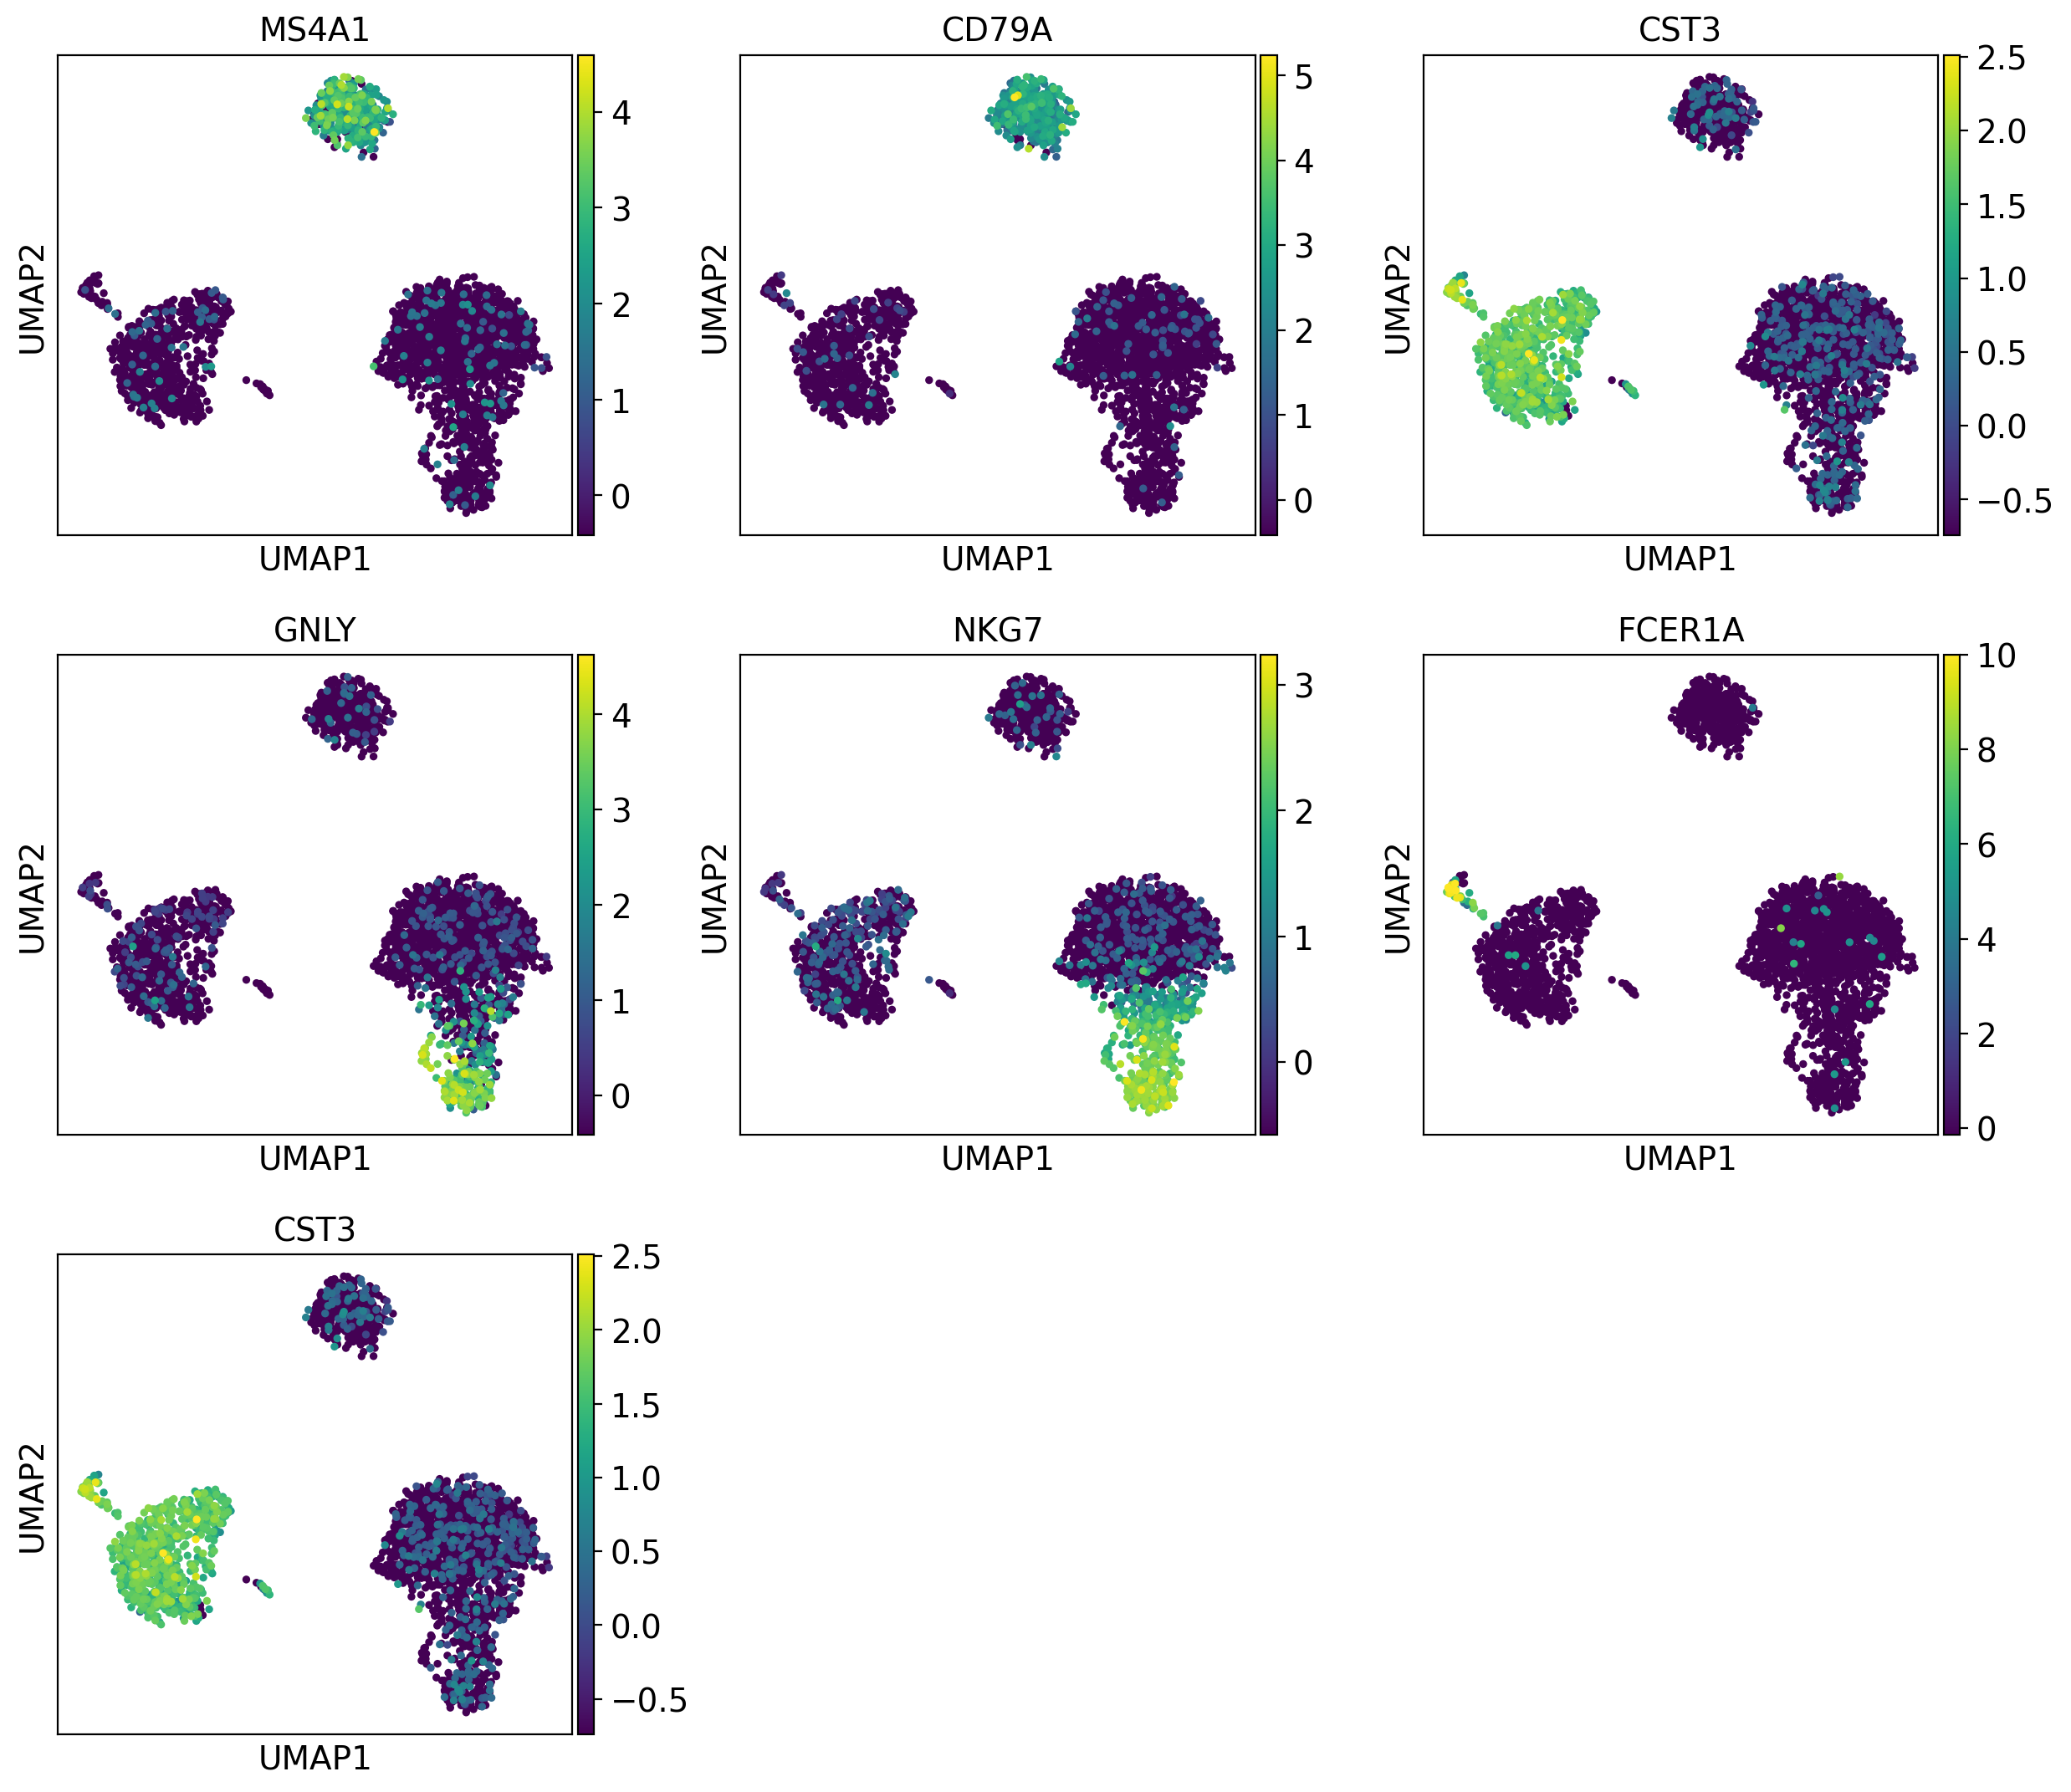

In [19]:
# 更換為表現量較高、不易被過濾掉的 marker
marker_genes = {
    'T cell':    ['IL7R', 'CD3E'],
    'B cell':    ['MS4A1', 'CD79A'],
    'Monocyte':  ['CD14', 'LYZ', 'CST3'],
    'NK cell':   ['GNLY', 'NKG7'],
    'DC':        ['FCER1A', 'CST3'],
}

# 把所有基因攤平成一個 list，並過濾掉不存在的
flat_markers = [g for genes in marker_genes.values() for g in genes if g in adata.var_names]
print("可用的 markers：", flat_markers)

sc.pl.umap(adata, color=flat_markers, ncols=3)

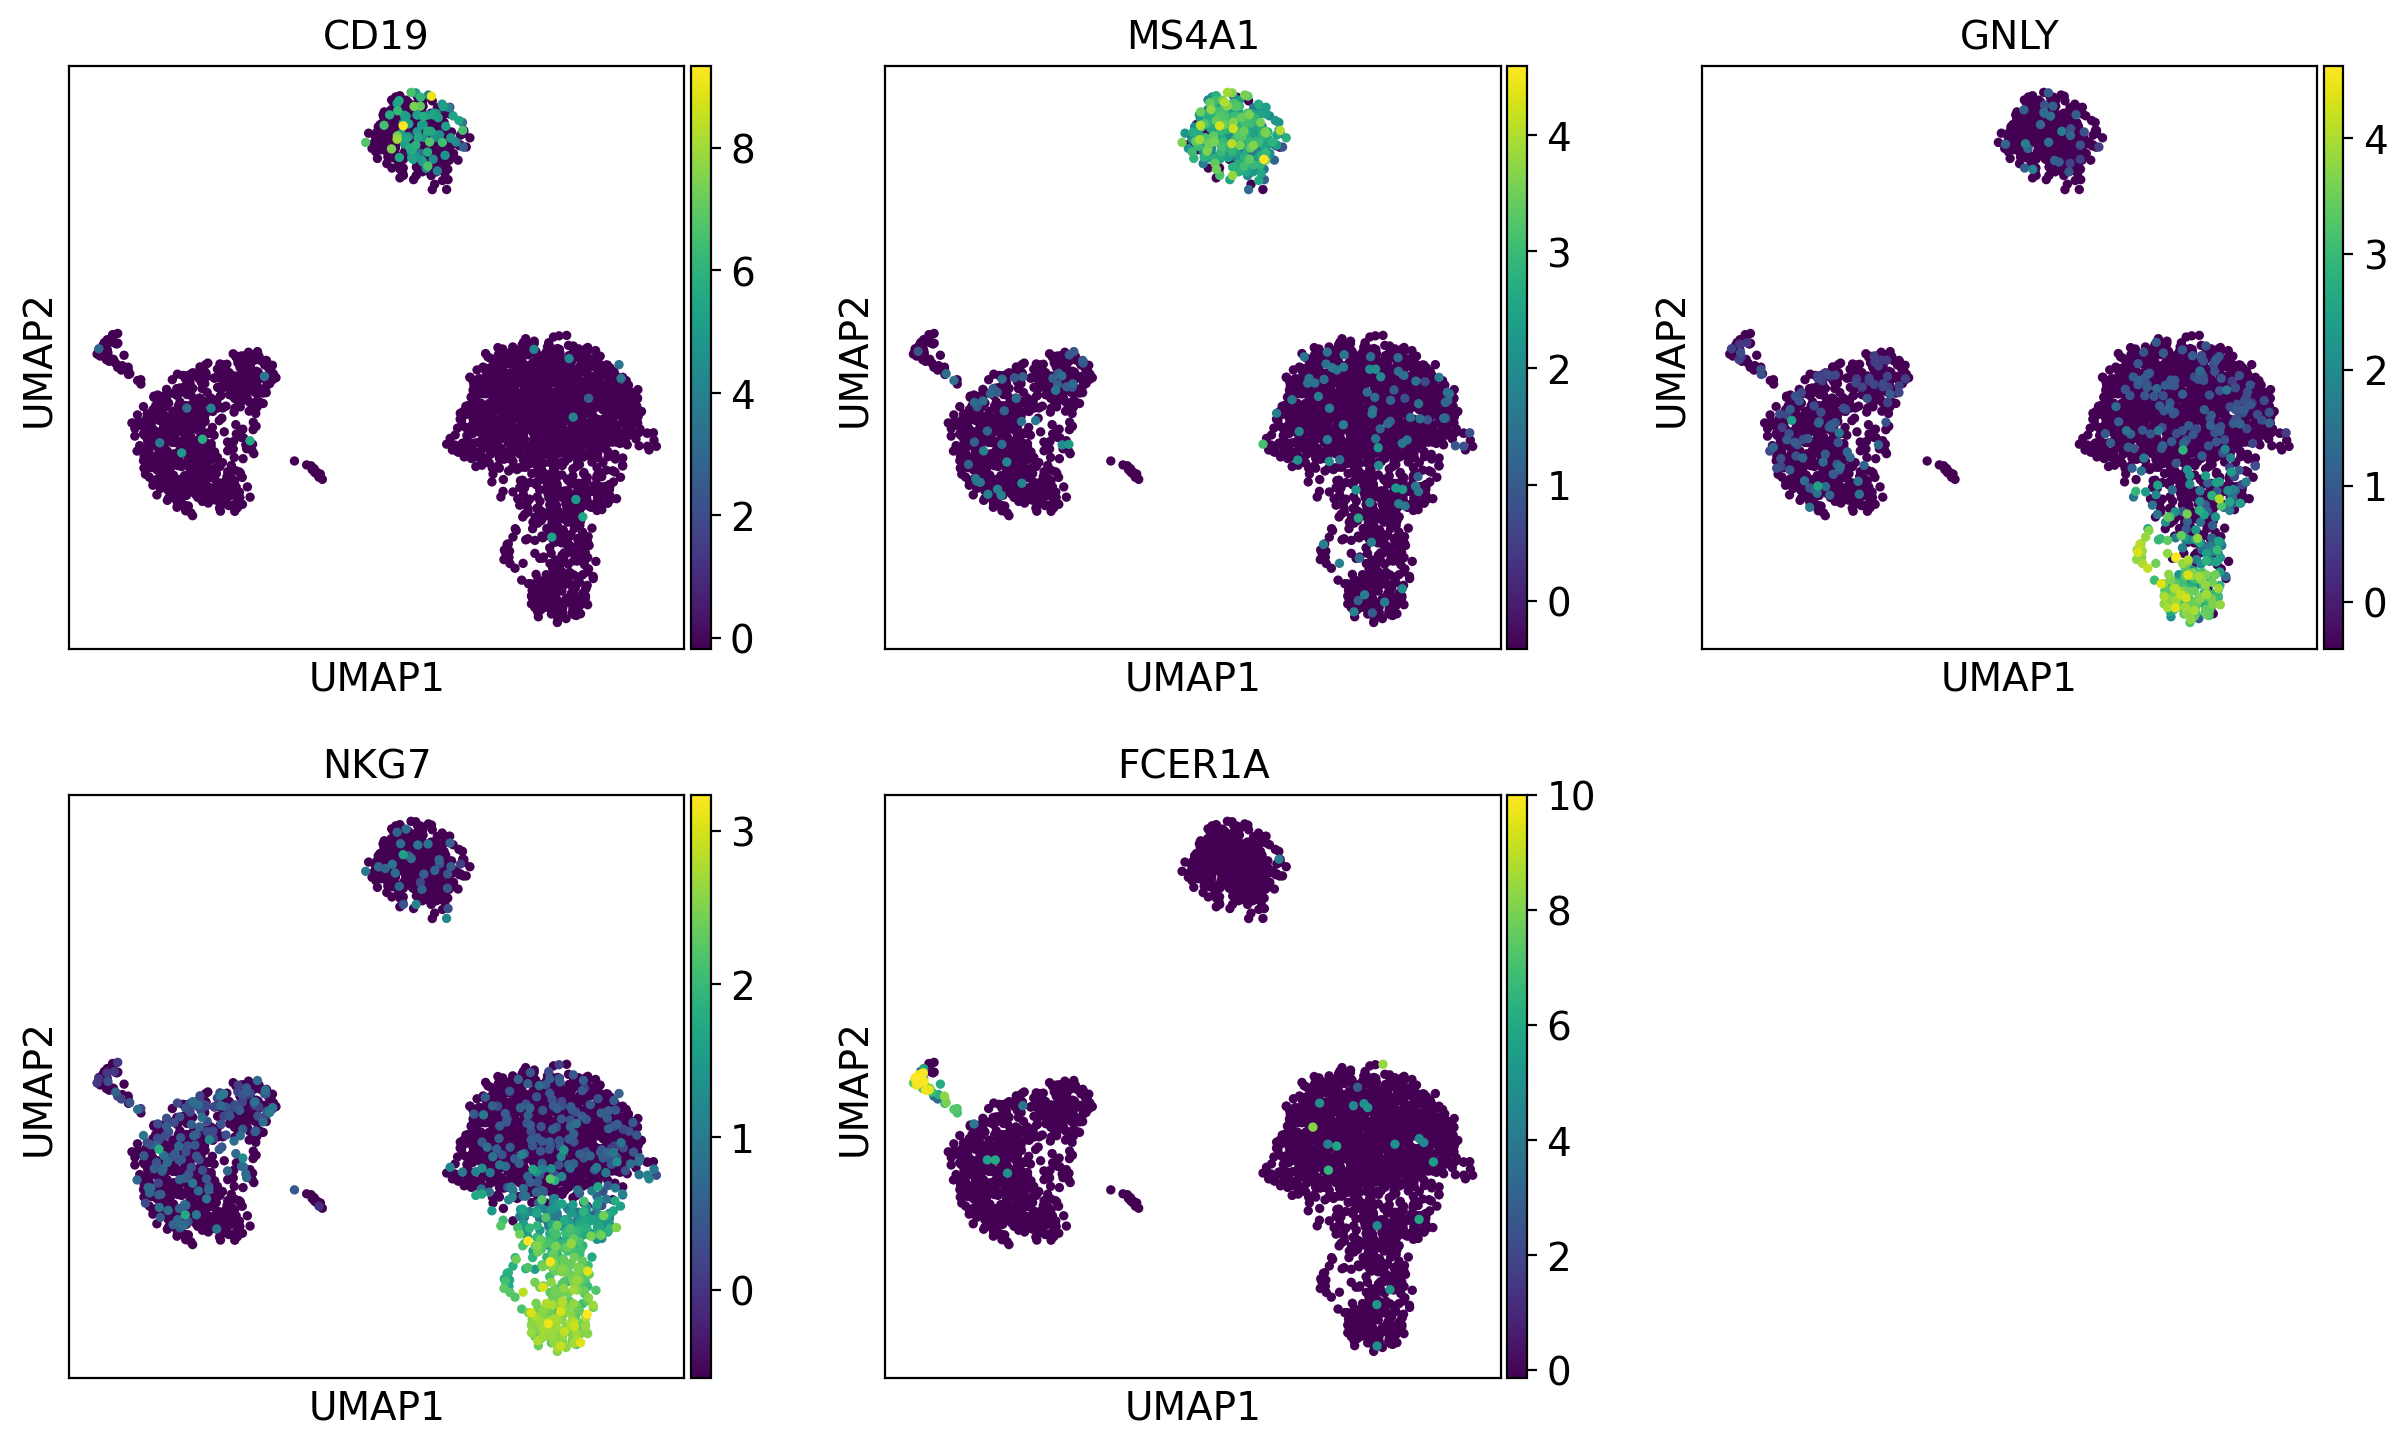

In [26]:
marker_genes = ['CD3D', 'IL7R', 'CD19', 'MS4A1', 'CD14', 'LYZ', 'GNLY', 'NKG7', 'FCER1A']

# Filter to genes that are in our dataset
marker_genes = [g for g in marker_genes if g in adata.var_names]

sc.pl.umap(adata, color=marker_genes, ncols=3)

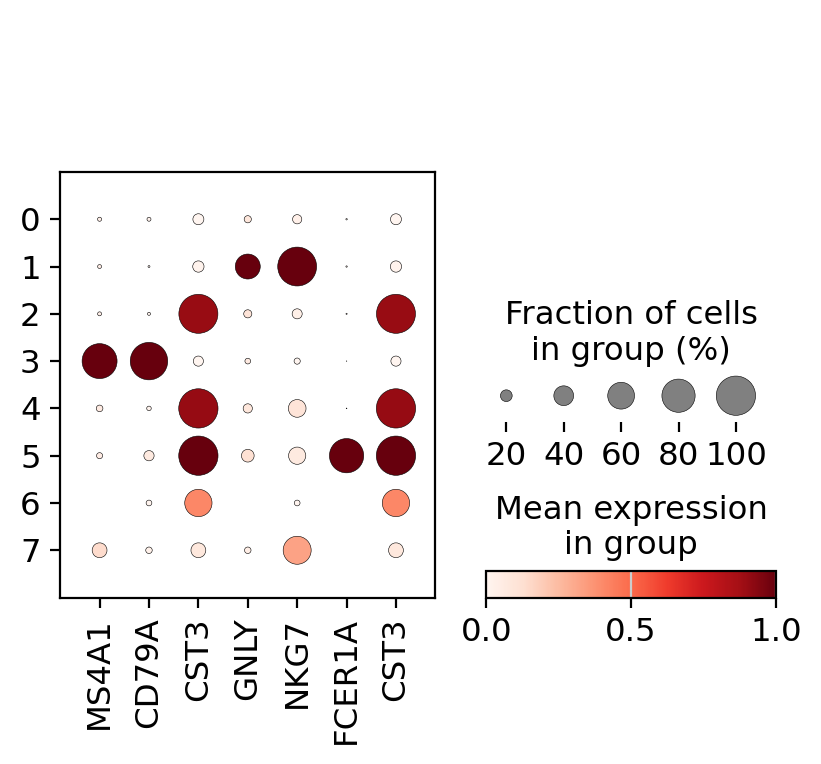

In [28]:
sc.pl.dotplot(adata, flat_markers, groupby='leiden_0.8', standard_scale='var')

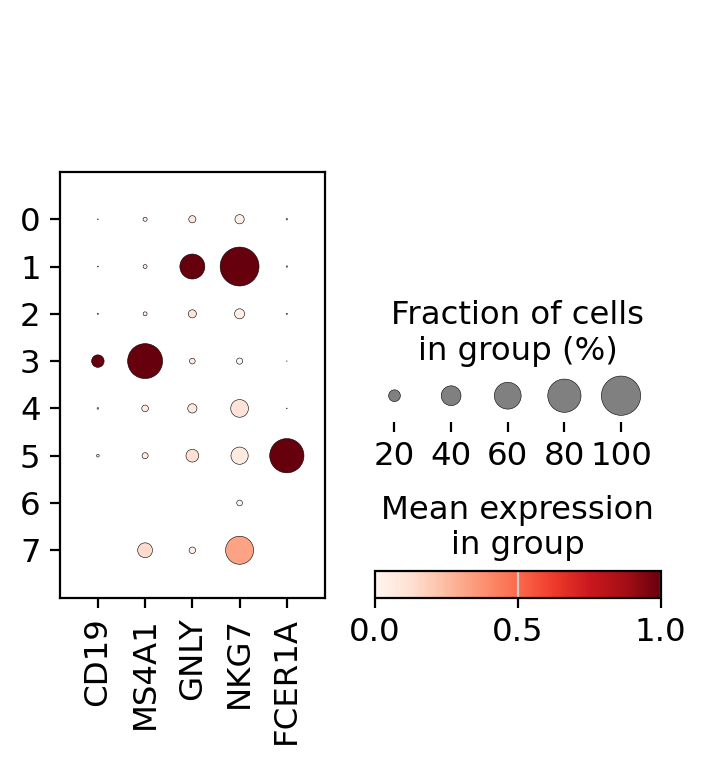

In [27]:
# Dot plot: expression of each marker gene in each cluster
sc.pl.dotplot(adata, marker_genes, groupby='leiden', standard_scale='var')

# Q: Which cluster has high CD3D? That's T cells.
# Which cluster has high CD14? That's monocytes.
# Can you assign a cell type to each cluster number?

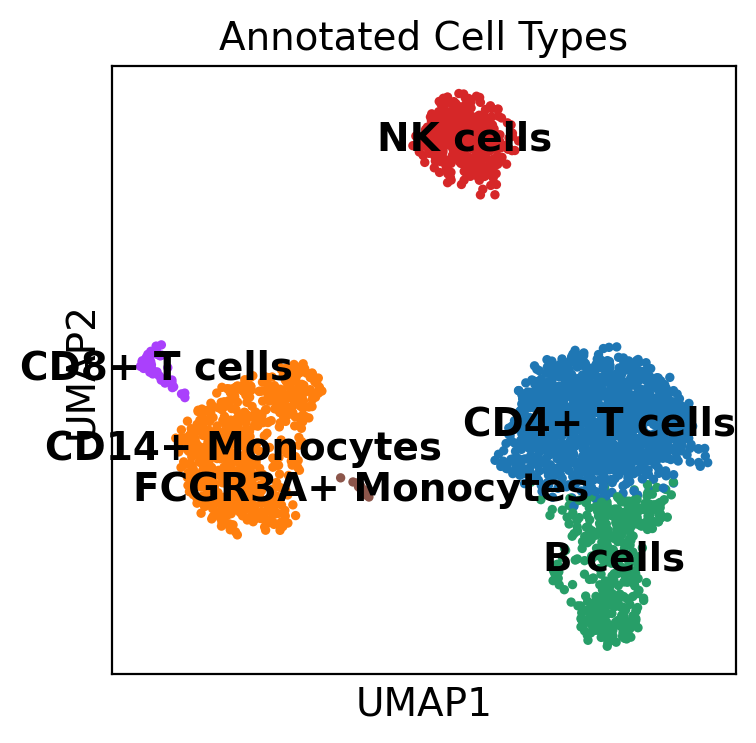

In [12]:
# Assign cell type names (fill in based on the dotplot above)
cluster_to_celltype = {
    '0': 'CD4+ T cells',
    '1': 'CD14+ Monocytes',
    '2': 'B cells',
    '3': 'NK cells',
    '4': 'CD8+ T cells',
    '5': 'FCGR3A+ Monocytes',
    '6': 'Dendritic cells',
    '7': 'Megakaryocytes',
}

adata.obs['cell_type'] = adata.obs['leiden'].map(
    lambda x: cluster_to_celltype.get(x, f'Cluster {x}')
)

sc.pl.umap(adata, color='cell_type', legend_loc='on data', title='Annotated Cell Types')

## 7. Find Marker Genes for Each Cluster

Instead of manually checking known markers, we can also ask: what genes are most specifically expressed in each cluster?

/usr/local/lib/python3.12/dist-packages/scanpy/tools/_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/usr/local/lib/python3.12/dist-packages/scanpy/tools/_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/usr/local/lib/python3.12/dist-packages/scanpy/tools/_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/usr/local/lib/python3.12/dist-packages/scanpy/tools/_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/usr/local/lib/python3.12/dist-packages/scanpy/tools/_rank_genes_groups.py:484: RuntimeWarning: invalid value encountered in log2
  self.stats[group_name, "logfoldchanges"] = np.log2(
/usr/local/lib/python3.12/dist-packages/scanpy/tools/_rank_genes_groups.py:484: 

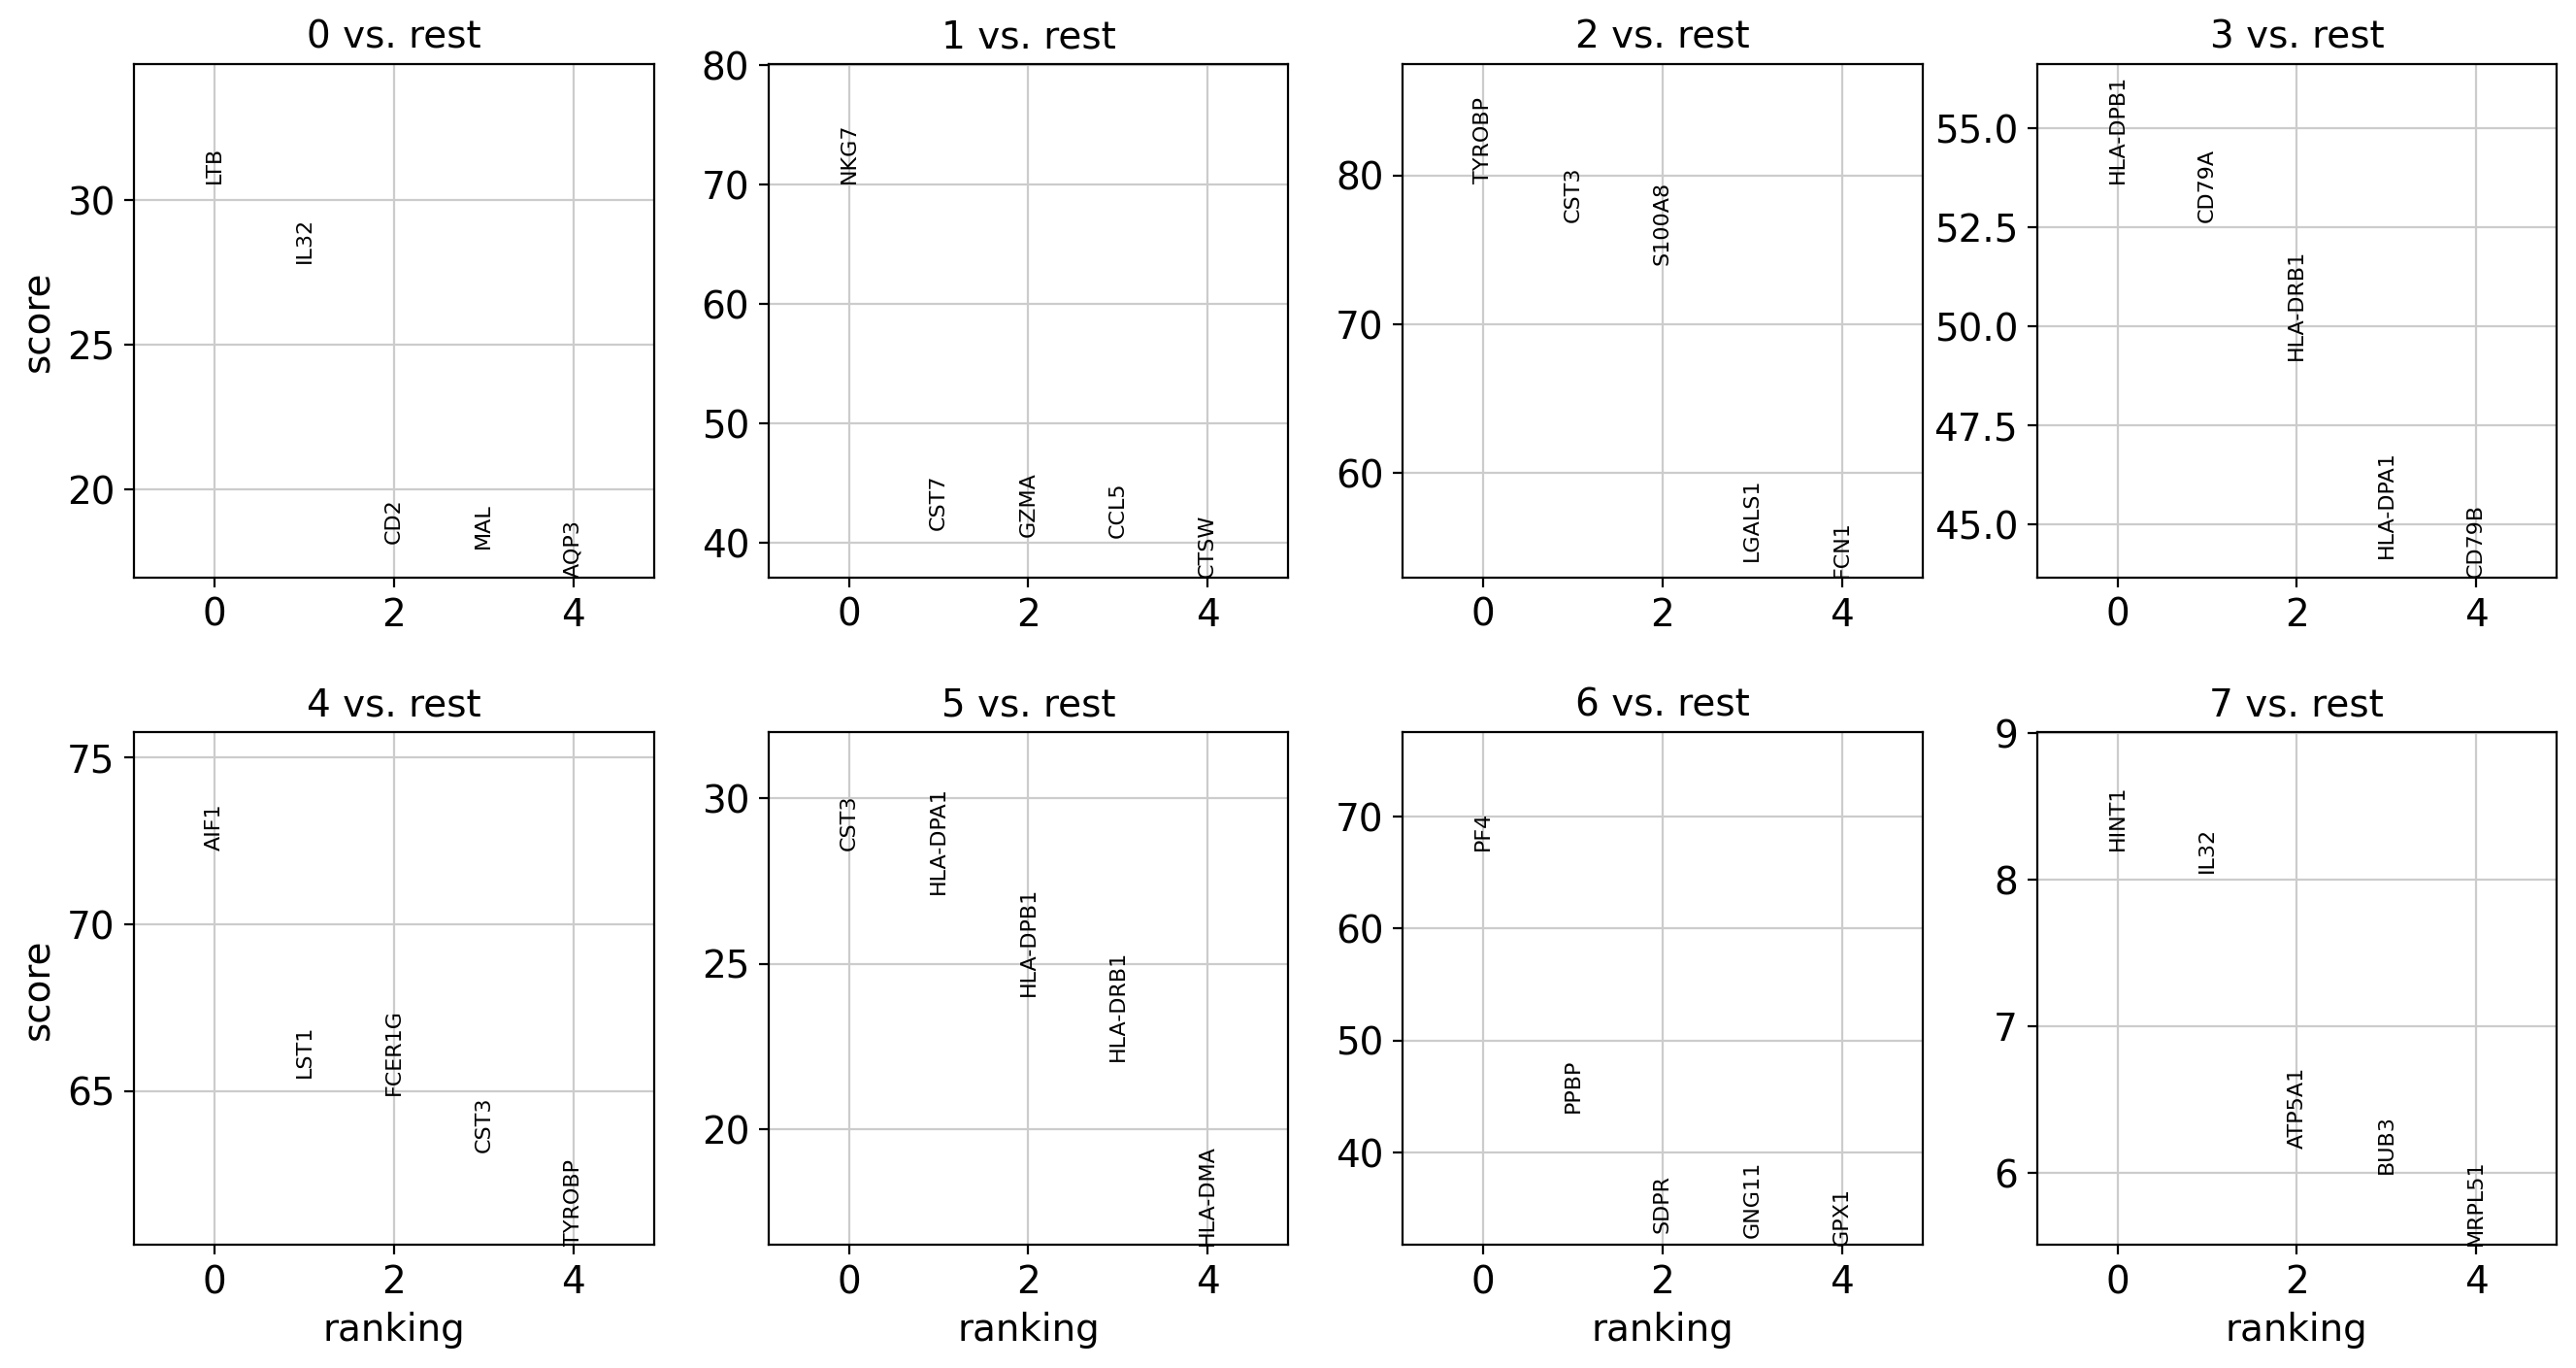

In [29]:
sc.tl.rank_genes_groups(adata, groupby='leiden', method='t-test')
sc.pl.rank_genes_groups(adata, n_genes=5, sharey=False)

# Q: Do the top marker genes for each cluster match the cell types you assigned?

## Reflection Questions

1. Change `resolution` to 0.9 and re-run. Some clusters split — do the subclusters make biological sense (e.g., CD4+ vs CD8+ T cells separating)?
2. The cluster-to-celltype mapping above may not be perfectly accurate. How would you validate your annotations?
3. This dataset is from blood. How would a tissue-specific dataset (e.g., tumor, brain) change what you'd expect to find?
4. Does single-cell biology interest you enough to continue to Phase 3 Track D?

# Phase 2 Track D — 單細胞 PBMC Clustering 複習筆記

---

## 1. Pipeline 整體邏輯

> 核心原則：先消除技術噪音 → 挑有用的基因 → 降維 → 算距離 → 分群＋視覺化

| 步驟 | 函數 | 生物意義 |
|------|------|---------|
| Normalization | `normalize_total` + `log1p` | 消除定序深度差異造成的假象 |
| Feature selection | `highly_variable_genes` | 從 32k 基因挑 ~2000 個最有分群能力的 |
| Scale | `scale(max_value=10)` | 避免高表現基因主導 PCA |
| PCA | `tl.pca` | 壓縮維度，肘軸圖判斷保留幾個 PC |
| 建鄰居圖 | `pp.neighbors(n_pcs=40)` | 在 PC 空間計算細胞間距離 |
| UMAP | `tl.umap` | 把高維距離壓成 2D 視覺化 |
| Leiden clustering | `tl.leiden` | 在鄰居圖上分群（與 UMAP 平行，非從 UMAP 分） |

---

## 2. Leiden Resolution

- **小（如 0.3）**→ 群數少，粒度粗（e.g. 所有 T cell 一群）
- **大（如 1.5）**→ 群數多，粒度細（e.g. CD4 naive vs CD4 memory 分開）

**如何選擇：**
1. 對照已知 marker gene，看每群是否有生物學上一致的表現
2. PBMC 已知約 7–10 種主要細胞類型，群數太少或太多都不合理
3. 試多個值比較 UMAP，選視覺上區塊與群對應最整齊的

```python
for res in [0.3, 0.5, 0.8, 1.2]:
    sc.tl.leiden(adata, resolution=res, key_added=f'leiden_{res}')
sc.pl.umap(adata, color=['leiden_0.3', 'leiden_0.5', 'leiden_0.8', 'leiden_1.2'])
```

---

## 3. Marker Gene 可能遺失的原因

CD3D 等 marker 不在 `adata.var_names` 的常見原因：

1. **被 filter_genes 過濾**：在非目標細胞裡表現量太低，整體太稀疏
2. **大小寫格式不符**：資料集存的是 `Cd3d` 或 `cd3d`
3. **用的是 Ensembl ID**：`ENSG000...` 而非基因符號

**診斷方式：**
```python
print(adata.var_names[:20].tolist())
matches = [g for g in adata.var_names if 'CD3' in g.upper()]
print(matches)
```

**PBMC3k 較穩健的 marker 替代清單：**
```python
marker_genes = {
    'T cell':   ['IL7R', 'CD3E'],
    'B cell':   ['MS4A1', 'CD79A'],
    'Monocyte': ['CD14', 'LYZ', 'CST3'],
    'NK cell':  ['GNLY', 'NKG7'],
    'DC':       ['FCER1A', 'CST3'],
}
```

---

## 4. Pipeline 的主觀性與 Bias

**單細胞分析的真實問題**：每個決策點（filter 標準、PC 數、resolution、marker gene 選擇）都會影響結果，"the analysis reflects the analyst"。

**應對原則：**
| 決策點 | 應對方式 |
|--------|---------|
| Filter 標準 | 明確報告標準；做 sensitivity analysis |
| PC 數 | 試 30/40/50，確認結論穩定 |
| Resolution | 對照 marker gene 驗證，不只看群數 |
| Marker gene | 用資料庫（CellMarker、PanglaoDB）而非自行猜測 |

**更根本的問題**：細胞類型本身是連續譜（e.g. naive → effector T cell 是分化連續體），分群本來就是人為把連續譜切成離散類別。

---

## 5. AI 在單細胞分析中的角色

| 層面 | AI 現況 |
|------|---------|
| 細胞類型標注 | ✅ 已大量取代（CellTypist、scType、Azimuth） |
| QC filter 標準 | ✅ 部分自動化（scAutoQC） |
| 研究問題設計 | ❌ 仍需人判斷 |
| Batch effect 來源判斷 | ❌ 仍需領域知識 |
| 結果的生物意義驗證 | ❌ 仍需生物背景 |

> AI 正在取代**執行層面**的判斷，但**研究設計層面**仍需人——這也是生物背景最有價值的地方。

---

## 6. 注意事項

- `pip install` 出現 pandas 版本衝突的 ERROR 可忽略，不影響 scanpy 執行
- UMAP 和 Leiden clustering **都從同一個鄰居圖出發**，是平行關係，不是 Leiden 從 UMAP 上分群
- Normalization 方法和基因選擇對最終結果的影響 > clustering 演算法的選擇（Luecken & Theis, 2020）